In [1]:
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Machine Learning

1. Risk Stratification (Classification)
Early disease detection using tabular health indicators (age, BMI, labs, history)
2. Length of Stay Prediction (Regression)
Forecasting hospitalization duration from vitals, diagnosis codes, procedures
3. Patient Segmentation (Clustering)
Grouping patients into cohorts based on similarity in health and behavior
4. Medical Associations (Association Rules)
Mining co-occurrence patterns like BMI + hypertension → diabetes risk

1. https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction?resource=download
2. https://www.kaggle.com/datasets/aayushchou/hospital-length-of-stay-dataset-microsoft

## Risk Stratification

In [2]:
import pandas as pd

risk_stratification_df = pd.read_csv('/content/risk_stratification.csv')

In [3]:
risk_stratification_df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# EDA <PLACE HOLDER>

In [4]:
risk_stratification_df.shape

(918, 12)

In [5]:
risk_stratification_df.HeartDisease.value_counts()

,count
HeartDisease,
1,508
0,410


In [6]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix

In [7]:
y = risk_stratification_df["HeartDisease"]
X = risk_stratification_df.drop("HeartDisease", axis=1)

In [8]:
num_features = X.select_dtypes(include=["int64","float64"]).columns
cat_features = X.select_dtypes(include=["object"]).columns

In [9]:
num_features

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak'], dtype='object')

In [10]:
cat_features

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

In [11]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

In [12]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [13]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

In [14]:
model_log = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [15]:
model_rf = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200,
                                          random_state=42))
])

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
model_log.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [18]:
model_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [20]:
y_pred = model_log.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[68 14]
 [ 7 95]]
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        82
           1       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



In [21]:
cm = confusion_matrix(y_test, y_pred)

<Figure size 640x480 with 0 Axes>

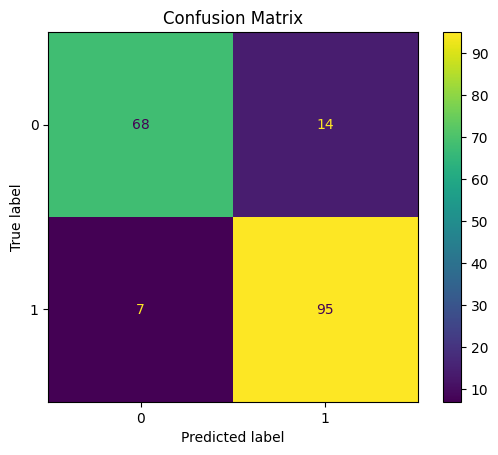

In [22]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure()
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [23]:
y_pred = model_rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[71 11]
 [ 7 95]]
              precision    recall  f1-score   support

           0       0.91      0.87      0.89        82
           1       0.90      0.93      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184



In [24]:
cm = confusion_matrix(y_test, y_pred)

<Figure size 640x480 with 0 Axes>

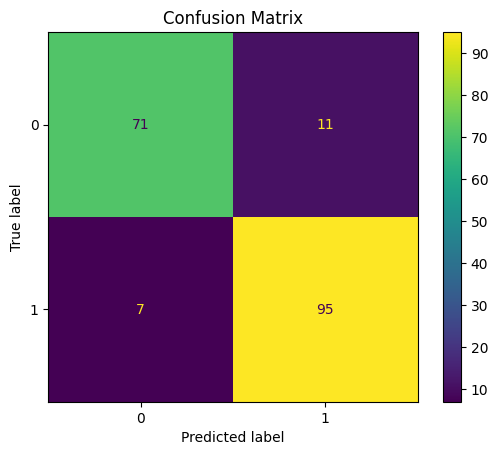

In [25]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure()
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [26]:
new_patient = pd.DataFrame([{
    "Age": 45,
    "Sex": "M",
    "ChestPainType": "ATA",
    "RestingBP": 135,
    "Cholesterol": 250,
    "FastingBS": 0,
    "RestingECG": "Normal",
    "MaxHR": 160,
    "ExerciseAngina": "N",
    "Oldpeak": 0.5,
    "ST_Slope": "Up"
}])

In [27]:
risk = model_log.predict(new_patient)
prob = model_log.predict_proba(new_patient)

print("Risk:", "High" if risk[0]==1 else "Low")
print("Probability:", prob)

Risk: Low
Probability: [[0.94098108 0.05901892]]


In [28]:
risk = model_rf.predict(new_patient)
prob = model_rf.predict_proba(new_patient)

print("Risk:", "High" if risk[0]==1 else "Low")
print("Probability:", prob)

Risk: Low
Probability: [[0.95 0.05]]


In [29]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve

In [30]:
y_pred = model_rf.predict(X_test)
y_prob = model_rf.predict_proba(X_test)[:, 1]   # Probability of class = 1

In [31]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)

Accuracy: 0.9021739130434783
F1-score: 0.9134615384615384
ROC-AUC: 0.9331061692969871


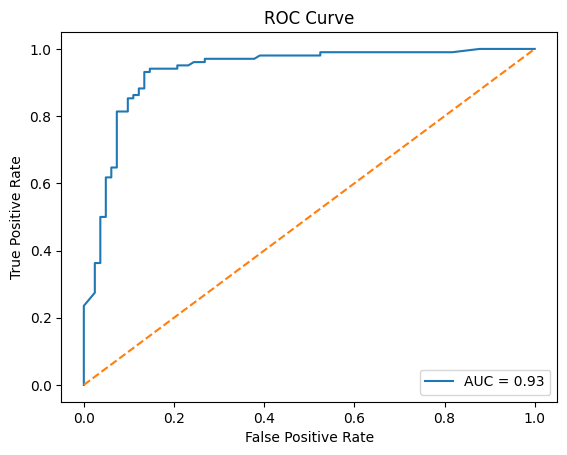

In [32]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [33]:
import joblib
joblib.dump(model_log, 'q1_model_lr.pkl')
print("✅ LOS model saved!")

joblib.dump(model_rf, 'q1_model_rf.pkl')
print("✅ LOS model saved!")


✅ LOS model saved!
✅ LOS model saved!


## Length of Stay

In [34]:
duration_forecasting_df = pd.read_csv('/content/duration_forecasting.csv')


duration_forecasting_df = duration_forecasting_df.sample(
    n=10000,
    random_state=42
)

In [35]:
duration_forecasting_df.head()

,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
75721,75722,10/19/2012,0,M,0,0,0,0,0,1,...,152.996500,14.0,1.062698,32.137835,75,6.4,4,10/23/2012,E,4
80184,80185,4/23/2012,0,M,0,0,0,0,0,0,...,147.976483,12.0,1.199566,29.079780,79,6.5,4,4/24/2012,B,1
19864,19865,9/7/2012,0,F,0,0,0,0,0,0,...,151.761622,12.0,1.079850,32.477699,74,6.5,7,9/9/2012,A,2
76699,76700,2/2/2012,0,F,0,0,0,0,0,0,...,147.310011,12.0,0.773003,29.181104,66,6.5,1,2/3/2012,B,1
92991,92992,4/22/2012,2,M,0,0,0,0,0,1,...,151.560766,15.0,1.196327,29.109964,72,7.1,1,4/27/2012,E,5


In [36]:
y = duration_forecasting_df["lengthofstay"]
X = duration_forecasting_df.drop(["lengthofstay",'vdate','discharged'], axis=1)

In [37]:
X.columns

Index(['eid', 'rcount', 'gender', 'dialysisrenalendstage', 'asthma', 'irondef',
       'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress',
       'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit',
       'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine',
       'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9', 'facid'],
      dtype='object')

In [38]:
X["rcount"] = X["rcount"].replace("5+", 5).astype(int)

In [39]:
num_features = X.select_dtypes(include=["int64","float64"]).columns
cat_features = X.select_dtypes(include=["object"]).columns

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [41]:
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [42]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

In [43]:
from sklearn.linear_model import LinearRegression

model_los_lr = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", LinearRegression())
])

In [44]:
from sklearn.ensemble import RandomForestRegressor

model_los_rf = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", RandomForestRegressor())
])

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [46]:
model_los_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['eid', 'rcount', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum',
       'substancedependence', 'psychologicaldisordermajor', 'depress',
       'psychother', 'fibrosisandother', 'malnutrition', 'hemo'...crit',
       'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine',
       'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'facid'], dtype='object'))])),
                ('regressor', LinearRegression())])

In [47]:
model_los_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['eid', 'rcount', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum',
       'substancedependence', 'psychologicaldisordermajor', 'depress',
       'psychother', 'fibrosisandother', 'malnutrition', 'hemo'...,
       'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine',
       'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'facid'], dtype='object'))])),
                ('regressor', RandomForestRegressor())])

In [48]:
y_pred = model_los_lr.predict(X_test)

In [49]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 1.1220602805883064
MAE: 0.8611241039824362
R2: 0.7752919378384006


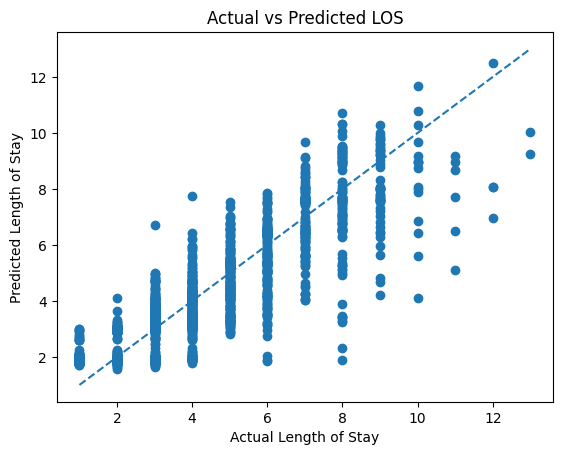

In [50]:
plt.figure()

plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")

plt.xlabel("Actual Length of Stay")
plt.ylabel("Predicted Length of Stay")
plt.title("Actual vs Predicted LOS")

plt.show()

In [51]:
y_pred = model_los_rf.predict(X_test)

In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 0.7974879309431585
MAE: 0.53803
R2: 0.8864898978406046


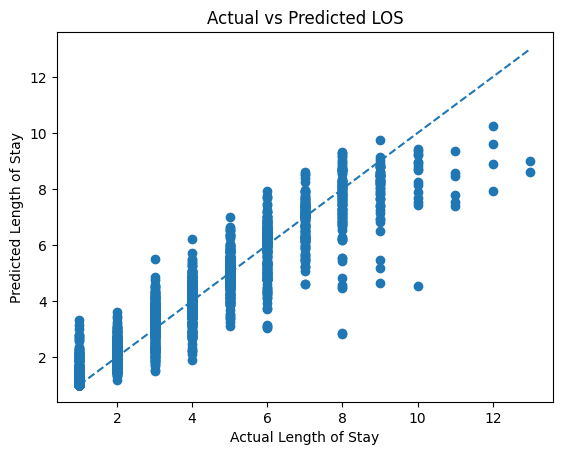

In [53]:
plt.figure()

plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")

plt.xlabel("Actual Length of Stay")
plt.ylabel("Predicted Length of Stay")
plt.title("Actual vs Predicted LOS")

plt.show()

## Patient Segmentation

In [54]:
np.random.seed(42)

# Load data
duration_forecasting_df = pd.read_csv('/content/duration_forecasting.csv')

duration_forecasting_df = duration_forecasting_df.sample(
    n=10000,
    random_state=42
)

id_cols = ["eid", "facid","vdate","discharged"]   # IDs
target_cols = ["lengthofstay"]  # outcome

df_cluster = duration_forecasting_df.drop(id_cols + target_cols, axis=1)

In [55]:
id_cols = ["eid", "facid","vdate","discharged"]
target_cols = ["lengthofstay"]

df_cluster = duration_forecasting_df.drop(
    columns=id_cols + target_cols,
    errors="ignore"
)

In [56]:
if "rcount" in df_cluster.columns:
    df_cluster["rcount"] = (
        df_cluster["rcount"]
        .replace("5+", 5)
        .astype(float)
    )

In [57]:
num_cols = df_cluster.select_dtypes(
    include=["int64", "float64"]
).columns

cat_cols = df_cluster.select_dtypes(
    include=["object"]
).columns

print("Numerical Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))

Numerical Columns: 22
Categorical Columns: 1


In [58]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [59]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [60]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [61]:
X_scaled = preprocessor.fit_transform(df_cluster)

print("Processed Shape:", X_scaled.shape)

Processed Shape: (10000, 24)


In [62]:
from sklearn.cluster import KMeans

wcss = []

k_range = range(2, 40)

for k in k_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

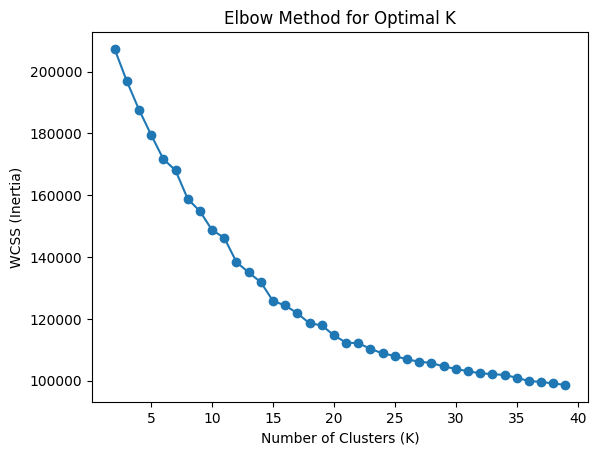

In [63]:
plt.figure()

plt.plot(k_range, wcss, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal K")

plt.show()

In [64]:
best_k = 20

In [65]:
final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

In [66]:
df_clustered = df_cluster.copy()

df_clustered["cluster"] = cluster_labels

In [67]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

sil_score = silhouette_score(X_scaled, cluster_labels)

ch_score = calinski_harabasz_score(X_scaled, cluster_labels)

print("Silhouette Score:", sil_score)
print("Calinski-Harabasz Score:", ch_score)

Silhouette Score: 0.08207267501149929
Calinski-Harabasz Score: 504.97544428704794


In [68]:
print("\nCluster Counts:")
print(df_clustered["cluster"].value_counts())


Cluster Counts:
cluster
6     1024
18    1001
4      964
13     947
3      939
0      936
16     617
15     463
5      405
2      402
1      393
17     356
9      346
14     337
7      323
11     284
12     193
8       52
19      10
10       8
Name: count, dtype: int64


In [69]:
num_cols2 = df_clustered.select_dtypes(
    include=["int64", "float64"]
).columns

cluster_summary = (
    df_clustered
    .groupby("cluster")[num_cols2]
    .mean()
)

cluster_summary

,rcount,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,...,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9
cluster,,,,,,,,,,,,,,,,,,,,,
0,4.006410,0.000000,0.000000,0.000000,0.000000,0.000000,0.066239,0.000000,0.000000,0.0,...,11.906695,10.347756,137.975508,141.614445,11.987179,1.119671,29.602241,73.023504,6.479327,1.808761
1,1.109415,0.000000,0.000000,0.137405,0.000000,0.000000,0.231552,0.000000,0.000000,0.0,...,9.948919,9.757697,137.842038,137.354138,12.951654,1.091766,29.888181,73.885496,6.415522,2.218830
2,1.034826,0.002488,0.000000,0.089552,0.000000,0.052239,0.815920,1.000000,0.007463,0.0,...,12.606592,9.117579,138.069680,142.037203,12.524876,1.107875,29.651713,73.751244,6.691169,2.047264
3,0.820021,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,...,12.932872,8.799539,137.808168,141.435257,12.784594,1.090016,29.871247,72.307774,6.728914,1.765708
4,0.485477,0.000000,0.000000,0.000000,0.000000,0.000000,0.009336,0.000000,0.000000,0.0,...,11.693422,10.296041,138.887322,125.687320,12.065526,1.277293,28.525808,70.663900,6.463382,1.570539
5,0.888889,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,16.809383,18.049136,138.326337,142.290201,11.950617,1.112400,29.848345,73.928395,6.486008,1.997531
6,0.508789,0.000000,0.000000,0.000000,0.000000,0.000000,0.005859,0.000000,0.000000,0.0,...,11.842855,10.127246,137.364804,145.479833,11.869792,1.114181,30.099819,86.483398,6.474105,1.391602
7,0.916409,0.000000,0.009288,0.501548,0.043344,0.126935,0.411765,0.024768,0.331269,0.0,...,11.445820,7.837926,137.893358,142.970945,26.597523,1.106444,29.859693,74.888545,6.501961,2.356037
8,0.980769,0.057692,0.096154,0.211538,0.057692,0.173077,0.365385,0.153846,0.019231,1.0,...,9.750962,9.233654,138.131402,138.467170,16.673077,1.091766,29.644362,74.980769,6.240385,2.480769


## Medical Association

In [70]:
!pip install mlxtend

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 133.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 125.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 155.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 159.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully un

In [71]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from mlxtend.frequent_patterns import apriori, association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [72]:
df = pd.read_csv('/content/duration_forecasting.csv')

#df = df.sample(n=10000, random_state=42)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [73]:
comorb_cols = [
    "asthma",
    "dialysisrenalendstage",
    "irondef",
    "pneum",
    "substancedependence",
    "psychologicaldisordermajor"
]

vital_cols = [
    "bmi",
    "glucose",
    "creatinine",
    "pulse"
]


df_assoc = df[comorb_cols + vital_cols].copy()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [74]:
imputer = SimpleImputer(strategy="median")

df_assoc[vital_cols] = imputer.fit_transform(
    df_assoc[vital_cols]
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [75]:
df_assoc[comorb_cols] = df_assoc[comorb_cols].fillna(0)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [76]:
scaler = StandardScaler()

df_assoc[vital_cols] = scaler.fit_transform(
    df_assoc[vital_cols]
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [77]:
df_assoc["high_bmi"] = (df_assoc["bmi"] > 1).astype(int)
df_assoc["high_glucose"] = (df_assoc["glucose"] > 1).astype(int)
df_assoc["high_pulse"] = (df_assoc["pulse"] > 1).astype(int)
df_assoc["high_creatinine"] = (df_assoc["creatinine"] > 1).astype(int)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [78]:
binary_cols = (
    comorb_cols +
    ["high_bmi","high_glucose","high_pulse","high_creatinine"]
)

transactions = df_assoc[binary_cols]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [79]:
transactions

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,asthma,dialysisrenalendstage,irondef,pneum,substancedependence,psychologicaldisordermajor,high_bmi,high_glucose,high_pulse,high_creatinine
0,0,0,0,0,0,0,0,1,1,1
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
99995,0,0,0,0,0,0,0,0,0,0
99996,0,0,0,0,0,0,0,0,0,1
99997,0,0,1,0,0,0,0,0,0,0
99998,0,0,0,0,0,0,0,0,0,0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [80]:
frequent_itemsets = apriori(
    transactions,
    min_support=0.01,   # appears in 5% patients
    use_colnames=True
)

frequent_itemsets

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets
0,0.03527,(asthma)
1,0.03642,(dialysisrenalendstage)
2,0.09494,(irondef)
3,0.03945,(pneum)
4,0.06306,(substancedependence)
5,0.23904,(psychologicaldisordermajor)
6,0.15891,(high_bmi)
7,0.15846,(high_glucose)
8,0.14890,(high_pulse)
9,0.15867,(high_creatinine)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [81]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.3
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [82]:
rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(dialysisrenalendstage),(irondef),0.03642,0.09494,0.01210,0.332235,3.499421,1.0,0.008642,1.355357,0.741234,0.101459,0.262187,0.229842
1,(dialysisrenalendstage),(psychologicaldisordermajor),0.03642,0.23904,0.01551,0.425865,1.781563,1.0,0.006804,1.325402,0.455276,0.059665,0.245512,0.245375
2,(pneum),(irondef),0.03945,0.09494,0.01238,0.313815,3.305403,1.0,0.008635,1.318974,0.726110,0.101467,0.241835,0.222107
3,(irondef),(psychologicaldisordermajor),0.09494,0.23904,0.03864,0.406994,1.702618,1.0,0.015946,1.283225,0.455958,0.130832,0.220713,0.284320
4,(pneum),(psychologicaldisordermajor),0.03945,0.23904,0.01688,0.427883,1.790008,1.0,0.007450,1.330079,0.459469,0.064524,0.248165,0.249250
5,(substancedependence),(psychologicaldisordermajor),0.06306,0.23904,0.02355,0.373454,1.562307,1.0,0.008476,1.214531,0.384145,0.084545,0.176637,0.235986


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [83]:
rules = rules.sort_values(
    by="lift",
    ascending=False
)
rules[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]].head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
0,(dialysisrenalendstage),(irondef),0.01210,0.332235,3.499421
2,(pneum),(irondef),0.01238,0.313815,3.305403
4,(pneum),(psychologicaldisordermajor),0.01688,0.427883,1.790008
1,(dialysisrenalendstage),(psychologicaldisordermajor),0.01551,0.425865,1.781563
3,(irondef),(psychologicaldisordermajor),0.03864,0.406994,1.702618
5,(substancedependence),(psychologicaldisordermajor),0.02355,0.373454,1.562307


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Deep Learning

1. Imaging Diagnostics (CNN)
X-ray, CT, MRI analysis for disease detection and staging
2. Sequence Modeling (RNN / LSTM)
Time-series modeling of vitals, labs, ICU signals for deterioration prediction
3. Sentiment Analysis (deep-learning version)
Neural text models (LSTM/CNN/Transformers) applied to patient feedback

## Imaging Diagnostics

1. https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
2. https://www.kaggle.com/datasets/shayanfazeli/heartbeat
3. https://www.kaggle.com/datasets/junaid6731/hospital-reviews-dataset

In [84]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [3]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 749.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 124.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 113.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.2/225.2 kB 18.3 MB/s eta 0:00:00


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

In [9]:
BASE_PATH = "/kaggle/input/chest-xray-pneumonia/chest_xray"

TRAIN_PATH = os.path.join(BASE_PATH, "train")
TEST_PATH  = os.path.join(BASE_PATH, "test")
VAL_PATH   = os.path.join(BASE_PATH, "val")

In [10]:
BASE_PATH = "/kaggle/input/chest-xray-pneumonia/chest_xray"

TRAIN_PATH = os.path.join(BASE_PATH, "train")
TEST_PATH  = os.path.join(BASE_PATH, "test")
VAL_PATH   = os.path.join(BASE_PATH, "val")

In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [12]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [13]:
train_data = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

Found 5216 images belonging to 2 classes.


In [14]:
val_data = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

Found 16 images belonging to 2 classes.


In [15]:
test_data = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [16]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False   # Freeze layers

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [17]:
model_s = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

In [18]:
model_s.compile(
    optimizer="adam",
    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall(),
        tf.keras.metrics.AUC()
    ]
)

NameError: name 'tf' is not defined

In [19]:
model_s.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [21]:
EPOCHS = 3

history = model_s.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

ValueError: You must call `compile()` before using the model.

In [22]:
# Already there: cnn_model.save('pneumoniamodel.keras')
# Rename if needed:
model_s.save('pneumonia_cnn_final.keras')  # After history plot (cell ~101)
print("✅ CNN saved as pneumonia_cnn_final.keras")


✅ CNN saved as pneumonia_cnn_final.keras


In [23]:
results = model_s.evaluate(test_data)

print("\nTest Results:")
print("Loss:", results[0])
print("Accuracy:", results[1])
print("Precision:", results[2])
print("Recall:", results[3])
print("AUC:", results[4])

ValueError: You must call `compile()` before using the model.

In [24]:
# Accuracy
plt.figure()
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


# Loss
plt.figure()
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

NameError: name 'history' is not defined

<Figure size 640x480 with 0 Axes>

In [25]:
from tensorflow.keras.preprocessing import image

In [26]:
sample_img = TEST_PATH + "/PNEUMONIA/person1_virus_6.jpeg"

In [27]:
img = image.load_img(
    sample_img,
    target_size=IMG_SIZE
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model_s.predict(img_array)[0][0]

print("Pneumonia Probability:", pred)

if pred > 0.5:
    print("Prediction: PNEUMONIA")
else:
    print("Prediction: NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
Pneumonia Probability: 0.32775563
Prediction: NORMAL


## Sequence Modelling

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [29]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shayanfazeli/heartbeat")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heartbeat' dataset.
Path to dataset files: /kaggle/input/heartbeat


In [30]:
import os

DATA_PATH = "/kaggle/input/heartbeat"

print(os.listdir(DATA_PATH))

['ptbdb_abnormal.csv', 'ptbdb_normal.csv', 'mitbih_test.csv', 'mitbih_train.csv']


In [31]:
train_df = pd.read_csv(
    DATA_PATH + "/mitbih_train.csv",
    header=None
)

test_df = pd.read_csv(
    DATA_PATH + "/mitbih_test.csv",
    header=None
)

In [32]:
df = pd.concat([train_df, test_df], axis=0)

# Shuffle
df = df.sample(frac=1, random_state=42)

# Take only 10K rows (small version)
df = df.sample(n=10000, random_state=42)

print("Final Shape:", df.shape)

Final Shape: (10000, 188)


In [33]:
X = df.iloc[:, :-1].values   # ECG signal (187 points)
y = df.iloc[:, -1].values   # Class

In [34]:
y = (y != 0).astype(int)

In [35]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [36]:
X_lstm = X_scaled.reshape(
    X_scaled.shape[0],
    X_scaled.shape[1],
    1
)

print("LSTM Shape:", X_lstm.shape)

LSTM Shape: (10000, 187, 1)


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X_lstm,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
model_seq = Sequential([

    LSTM(
        64,
        return_sequences=True,
        input_shape=(187, 1)
    ),

    Dropout(0.3),

    LSTM(32),

    Dense(1, activation="sigmoid")
])

In [39]:
model_seq.compile(
    optimizer="adam",
    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall(),
        tf.keras.metrics.AUC()
    ]
)

In [40]:
history = model_seq.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - accuracy: 0.7987 - auc: 0.5075 - loss: 0.5381 - precision: 0.3003 - recall: 0.0913 - val_accuracy: 0.8215 - val_auc: 0.5134 - val_loss: 0.4655 - val_precision: 0.4211 - val_recall: 0.0226
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.8258 - auc: 0.5127 - loss: 0.4621 - precision: 0.6438 - recall: 0.0372 - val_accuracy: 0.8215 - val_auc: 0.5148 - val_loss: 0.4661 - val_precision: 0.4211 - val_recall: 0.0226
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.8234 - auc: 0.5022 - loss: 0.4669 - precision: 0.6577 - recall: 0.0286 - val_accuracy: 0.8215 - val_auc: 0.5135 - val_loss: 0.4657 - val_precision: 0.4211 - val_recall: 0.0226
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.8252 - auc: 0.5171 - loss: 0.4626 - precision: 0.6725 - recall: 0.0387 - val_accuracy: 0.8220 - val_auc: 0.5114 - val_loss: 0.4679 - val_precision: 0.4500 - val_recall: 0.0254
Epoch 5/15
125/125 ━━━━━

In [41]:
results = model_seq.evaluate(X_test, y_test)

print("\nTest Results")
print("Loss:", results[0])
print("Accuracy:", results[1])
print("Precision:", results[2])
print("Recall:", results[3])
print("AUC:", results[4])

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8259 - auc: 0.5271 - loss: 0.4629 - precision: 0.5874 - recall: 0.0390

Test Results
Loss: 0.46539801359176636
Accuracy: 0.8245000243186951
Precision: 0.5714285969734192
Recall: 0.033898305147886276
AUC: 0.5217124223709106


In [42]:
y_pred = (model_seq.predict(X_test) > 0.5).astype(int)

print(classification_report(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
              precision    recall  f1-score   support

           0       0.83      0.99      0.90      1646
           1       0.57      0.03      0.06       354

    accuracy                           0.82      2000
   macro avg       0.70      0.51      0.48      2000
weighted avg       0.78      0.82      0.75      2000



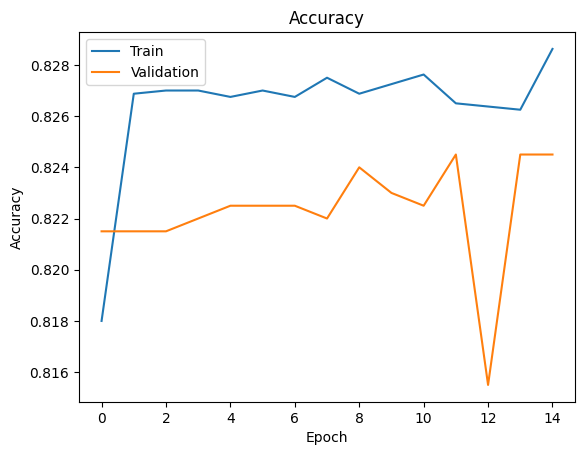

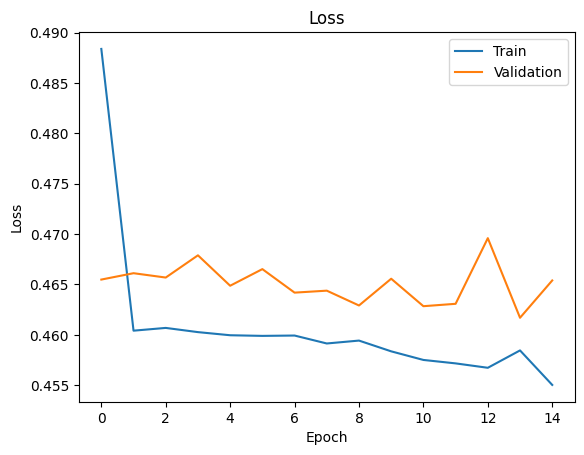

In [43]:
# Accuracy
plt.figure()
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


# Loss
plt.figure()
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [44]:
model_seq.save("model_lstm.keras")

## Sentiment Analysis

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("junaid6731/hospital-reviews-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'hospital-reviews-dataset' dataset.
Path to dataset files: /kaggle/input/hospital-reviews-dataset


In [3]:
import numpy as np
import pandas as pd
import torch

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from sklearn.metrics import precision_score, recall_score, matthews_corrcoef

In [6]:
import os

DATA_PATH = "/kaggle/input/hospital-reviews-dataset"

print(os.listdir(DATA_PATH))

['hospital.csv']


In [7]:
df = pd.read_csv(DATA_PATH + "/hospital.csv")
print(df.head())
print(df.shape)

                                            Feedback  Sentiment Label  \
0  Good and clean hospital. There is great team o...                1   
1  Had a really bad experience during discharge. ...                1   
2  I have visited to take my second dose and Proc...                1   
3   That person was slightly clueless and offered...                1   
4  There is great team of doctors and good OT fac...                0   

   Ratings  Unnamed: 3  
0        5         NaN  
1        5         NaN  
2        4         NaN  
3        3         NaN  
4        1         NaN  
(996, 4)


In [8]:
df = df.drop(columns=["Unnamed: 3"], errors="ignore")

In [9]:
df = df.rename(columns={
    "Feedback": "text",
    "Sentiment Label": "label"
})

In [10]:
df = df.dropna(subset=["text", "label"])

In [11]:
print(df.head())
print(df["label"].value_counts())

                                                text  label  Ratings
0  Good and clean hospital. There is great team o...      1        5
1  Had a really bad experience during discharge. ...      1        5
2  I have visited to take my second dose and Proc...      1        4
3   That person was slightly clueless and offered...      1        3
4  There is great team of doctors and good OT fac...      0        1
label
1    728
0    268
Name: count, dtype: int64


In [12]:
model_name = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

In [13]:
dataset = Dataset.from_pandas(df)

In [14]:
def tokenize(batch):

    return tokenizer(
        batch["text"],
        padding=True,
        truncation=True,
        max_length=128
    )


dataset = dataset.map(tokenize, batched=True)

Map:   0%|          | 0/996 [00:00<?, ? examples/s]

In [15]:
dataset = dataset.train_test_split(
    test_size=0.2,
    seed=42
)

In [16]:
dataset = dataset.rename_column("label", "labels")

dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [17]:
training_args = TrainingArguments(

    output_dir="./bert_patient_reviews",

    eval_strategy="epoch",

    per_device_train_batch_size=8,   # small dataset
    per_device_eval_batch_size=8,

    num_train_epochs=5,   # more epochs (small data)

    learning_rate=2e-5,

    logging_steps=20,

    save_strategy="epoch",

    load_best_model_at_end=True,

    report_to="none"
)

In [18]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=dataset["train"],
    eval_dataset=dataset["test"]
)

In [20]:
trainer.train()

RuntimeError: `fused=True` requires all the params to be floating point Tensors of supported devices: ['mps', 'cuda', 'xpu', 'hpu', 'cpu', 'mtia', 'privateuseone'] but torch.float32 and xla

In [ ]:
# Already: model.save_pretrained('sentimentmodeldir')
# Zip it:
!zip -r sentiment_model.zip sentimentmodeldir/
print("✅ BERT zipped!")


In [ ]:
preds = trainer.predict(dataset["test"])

y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=1)

In [ ]:
from sklearn.metrics import precision_score, recall_score, matthews_corrcoef, accuracy_score

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("MCC      :", mcc)

In [ ]:
def predict_sentiment(text):

    device = next(model.parameters()).device   # detect GPU/CPU

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # Move inputs to same device as model
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)

        probs = torch.softmax(outputs.logits, dim=1)

    return probs.cpu().numpy()   # move back to CPU for printing

In [ ]:
review = "Doctors were careless and nurses were rude"

print(predict_sentiment(review))

In [ ]:
def predict_sentiment_label(text):

    probs = predict_sentiment(text)[0]

    if probs[1] > probs[0]:
        return "Positive Review", probs
    else:
        return "Negative Review", probs


print(predict_sentiment_label(review))

In [ ]:
save_path = "./clinicalbert_model"

tokenizer.save_pretrained(save_path)
model.save_pretrained(save_path)

**Pickling**